# STO-DA Step 2 — Pyomo + HiGHS Scenario-Count Convergence

This notebook selects the retained scenario count \(K\) **without touching the 127 held-out OOS days**.

### Selection workflow

1. Select a deterministic 24-day validation subset from the 304-day development period, spanning the range of daily net-load conditions.
2. Use the primary uncertainty level \(\alpha=0.20\).
3. Solve STO-DA for
   \[
   K\in\{5,10,20,30,50,75,100\}
   \]
   in both grid-connected (GC) and islanded (IS) modes.
4. Apply the day-ahead policy to the measured realized day using the **same recourse partition as DET**:
   - fixed first-stage DG commitment \(u_t^{DG}\),
   - fixed first-stage BESS operating mode \(y_t^B\),
   - adaptive continuous dispatch magnitudes.
5. Compare paired realized costs against \(K=100\), together with solve time and 95% confidence intervals.
6. Choose the smallest \(K\) satisfying the pre-specified stability criterion in both GC and IS.

This is a **model-selection / convergence** experiment. It is not part of the final held-out performance results.

In [5]:
# Run only if the environment does not already contain these packages.
%pip install -q pyomo highspy pandas numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pyomo.environ as pyo

ROOT = Path.cwd()

def find_file(filename):
    candidates = [
        ROOT / filename,
        ROOT / 'data' / filename,
        ROOT / 'config' / filename,
        Path('/mnt/data') / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f'Could not locate {filename}. Tried: {candidates}')

DEV_FILE = find_file('rye_development_304days.csv')
for param_name in ['study_parameters_frozen_v3.json','study_parameters_frozen_v2.json','study_parameters_frozen_v1.json']:
    try:
        PARAM_FILE = find_file(param_name)
        break
    except FileNotFoundError:
        PARAM_FILE = None
if PARAM_FILE is None:
    raise FileNotFoundError('No study-parameter JSON found.')

dev = pd.read_csv(DEV_FILE)
with open(PARAM_FILE,'r',encoding='utf-8') as f:
    CFG=json.load(f)

print('Development file:',DEV_FILE)
print('Parameter file:',PARAM_FILE)
print('Development days:',dev['date_utc'].nunique())

Development file: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_STO_K_Convergence_Step\data\rye_development_304days.csv
Parameter file: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_STO_K_Convergence_Step\config\study_parameters_frozen_v3.json
Development days: 304


## 1. Frozen physical and economic parameters

The model uses the same physical/economic assumptions as the validated DET/PF baseline. Grid export remains a study extension with

\[
c_t^{sell}=0.2c_t^{buy},\qquad c_t^{buy}=c_t^{spot}+0.05.
\]

Because \(c_t^{buy}>c_t^{sell}\ge0\) for the Rye data, simultaneous import and export is strictly dominated. Therefore the stochastic model does not require a scenario-specific grid-direction binary, which substantially reduces MILP size without changing the optimum.

In [7]:
T = CFG['time']['T_hours']; DT = CFG['time']['delta_t_h']
PV_RATED = CFG['rye_physical_system']['pv_rated_kwp']; WIND_RATED = CFG['rye_physical_system']['wind_rated_kw']
BESS_E = CFG['rye_physical_system']['bess_energy_kwh']; P_CH_MAX = CFG['rye_physical_system']['bess_charge_max_kw']; P_DIS_MAX = CFG['rye_physical_system']['bess_discharge_max_kw']
ETA_CH = CFG['rye_physical_system']['eta_charge']; ETA_DIS = CFG['rye_physical_system']['eta_discharge']
SOC_MIN = CFG['bess_study_settings']['soc_min']; SOC_MAX = CFG['bess_study_settings']['soc_max']; SOC_INIT = CFG['bess_study_settings']['soc_initial']; SOC_TERM = CFG['bess_study_settings']['soc_terminal']
DG_MIN = CFG['study_added_diesel_generator']['p_min_kw']; DG_MAX = CFG['study_added_diesel_generator']['p_max_kw']; C_DG = CFG['study_added_diesel_generator']['marginal_cost_nok_per_kwh']
GRID_IMPORT_MAX = CFG['grid']['import_max_kw']; GRID_EXPORT_MAX = CFG['grid']['export_max_kw']; GRID_TARIFF = CFG['grid']['energy_tariff_nok_per_kwh']; SELL_FACTOR = CFG['grid']['sell_price_fraction_of_buy']
CRIT_SHARE = CFG['load_priority']['critical_fraction']; NCRIT_SHARE = CFG['load_priority']['noncritical_fraction']
C_BATT = CFG['objective_coefficients']['battery_throughput_nok_per_kwh']; C_CURT = CFG['objective_coefficients']['renewable_curtailment_nok_per_kwh']; C_SHED_N = CFG['objective_coefficients']['noncritical_shedding_penalty_nok_per_kwh']; C_SHED_C = CFG['objective_coefficients']['critical_shedding_penalty_nok_per_kwh']
BASE_SEED = CFG['uncertainty']['random_seed']
K_CANDIDATES = sorted(CFG['uncertainty'].get('reduced_scenario_candidates',[5,10,20,30,50,75,100]))
K_REF = CFG['uncertainty'].get('convergence_reference_K', max(K_CANDIDATES))
PRIMARY_ALPHA = CFG['uncertainty'].get('convergence_primary_alpha',0.20)
COST_TOL_PCT = CFG['uncertainty'].get('convergence_cost_tolerance_percent',0.50)
N_VALIDATION_DAYS = CFG['evaluation'].get('scenario_count_validation_days',24)
CONFIDENCE = CFG['evaluation'].get('confidence_level',0.95)

print('K candidates:',K_CANDIDATES)
print('Reference K:',K_REF)
print('Primary alpha:',PRIMARY_ALPHA)
print('Validation days:',N_VALIDATION_DAYS)
print('Cost tolerance:',COST_TOL_PCT,'%')

K candidates: [5, 10, 20, 30, 50, 75, 100]
Reference K: 100
Primary alpha: 0.2
Validation days: 24
Cost tolerance: 0.5 %


## 2. Deterministic development-day validation subset

To avoid selecting \(K\) on the final test set, this notebook uses 24 days from the development period. Days are selected deterministically across quantiles of daily **net deficit**

\[
E_{net,d}=\sum_t (P^{load}_{t,d}-P^{PV}_{t,d}-P^{W}_{t,d})\Delta t,
\]

so the subset spans renewable-surplus through high-deficit conditions.

In [8]:
def build_daily_table(df):
    g=(df.groupby('date_utc',as_index=False)
       .agg(load_kwh=('load_kw','sum'), pv_kwh=('pv_clean_kw','sum'), wind_kwh=('wind_clean_kw','sum'), peak_load_kw=('load_kw','max')))
    g['renewable_kwh']=g['pv_kwh']+g['wind_kwh']
    g['net_deficit_kwh']=g['load_kwh']-g['renewable_kwh']
    return g.sort_values('net_deficit_kwh').reset_index(drop=True)


def select_quantile_days(daily,n_days=24):
    qs=np.linspace(0.02,0.98,n_days)
    targets=np.quantile(daily['net_deficit_kwh'],qs)
    chosen=[]; used=set()
    for q,target in zip(qs,targets):
        order=np.argsort(np.abs(daily['net_deficit_kwh'].to_numpy()-target))
        for pos in order:
            date=str(daily.iloc[pos]['date_utc'])
            if date not in used:
                used.add(date)
                row=daily.iloc[pos].to_dict(); row['selection_quantile']=q
                chosen.append(row); break
    return pd.DataFrame(chosen).sort_values('selection_quantile').reset_index(drop=True)

daily_dev=build_daily_table(dev)
validation_days=select_quantile_days(daily_dev,N_VALIDATION_DAYS)
display(validation_days[['selection_quantile','date_utc','load_kwh','renewable_kwh','net_deficit_kwh','peak_load_kw']])
assert len(validation_days)==N_VALIDATION_DAYS
assert validation_days['date_utc'].nunique()==N_VALIDATION_DAYS

,selection_quantile,date_utc,load_kwh,renewable_kwh,net_deficit_kwh,peak_load_kw
0,0.020000,2020-10-17,474.327828,2440.237667,-1965.909839,26.129693
1,0.061739,2020-03-23,512.334154,1923.642326,-1411.308172,55.132996
2,0.103478,2020-05-01,441.589500,1533.474664,-1091.885164,54.242013
3,0.145217,2020-01-19,564.465812,1538.318167,-973.852355,51.261711
4,0.186957,2020-10-20,630.692132,1430.053267,-799.361134,38.520471
5,0.228696,2020-09-18,382.227522,1052.123220,-669.895697,23.802947
6,0.270435,2020-07-05,349.922442,890.686501,-540.764058,21.073158
7,0.312174,2020-09-20,373.739519,775.269381,-401.529862,22.423004
8,0.353913,2020-06-11,358.651916,694.087830,-335.435915,19.990069
9,0.395652,2020-06-24,342.811367,628.309328,-285.497962,19.199591


In [9]:
def stable_seed(*parts, base=BASE_SEED):
    value=int(base)
    for p in parts:
        for ch in str(p):
            value=(value*131+ord(ch))%(2**32-1)
    return value


def get_day(df,date_string):
    x=df[df['date_utc'].astype(str)==str(date_string)].copy().sort_values('hour_utc')
    if len(x)!=24: raise ValueError(f'{date_string}: expected 24 rows, got {len(x)}')
    day=pd.DataFrame({'hour':np.arange(24),'pv':x['pv_clean_kw'].to_numpy(float),'wind':x['wind_clean_kw'].to_numpy(float),'load':x['load_kw'].to_numpy(float),'spot':x['spot_price_nok_per_kwh'].to_numpy(float)})
    day['buy_price']=day['spot']+GRID_TARIFF; day['sell_price']=SELL_FACTOR*day['buy_price']
    day['load_crit']=CRIT_SHARE*day['load']; day['load_ncrit']=NCRIT_SHARE*day['load']
    return day


def make_point_forecast(actual,alpha,seed):
    rng=np.random.default_rng(seed); fc=actual.copy()
    for col,cap in [('pv',PV_RATED),('wind',WIND_RATED),('load',None)]:
        e=np.clip(rng.normal(0.0,alpha,size=24),-0.80,1.50)
        v=actual[col].to_numpy(float)/(1.0+e); v=np.maximum(v,0.0)
        if cap is not None: v=np.minimum(v,cap)
        fc[col]=v
    fc['load_crit']=CRIT_SHARE*fc['load']; fc['load_ncrit']=NCRIT_SHARE*fc['load']
    return fc

## 3. Load the BRA templates

Run the updated Notebook 04 first so `bra_outputs/` contains all seven candidate files. The saved standard-normalized template \(z\) is scaled by the current \(\alpha\):

\[
e_{t,s}=\alpha z_{t,s}.
\]

In [10]:
def find_bra_file(K):
    name=f'bra_alpha20_N5000_K{K}.npz'
    candidates=[ROOT/'bra_outputs'/name, ROOT/name, Path('/mnt/data')/'bra_outputs'/name]
    for p in candidates:
        if p.exists(): return p
    raise FileNotFoundError(f'Missing {name}. Run updated Notebook 04 first. Tried: {candidates}')


def load_bra_template(K,alpha):
    p=find_bra_file(K); z=np.load(p)
    if 'z_template' in z.files:
        z_template=z['z_template'].astype(float)
    else:
        alpha_template=float(z['alpha']) if 'alpha' in z.files else 0.20
        z_template=z['errors'].astype(float)/alpha_template
    errors=alpha*z_template
    probs=z['probability'].astype(float); probs=probs/probs.sum()
    return errors,probs

for K in K_CANDIDATES:
    e,p=load_bra_template(K,PRIMARY_ALPHA)
    assert e.shape==(K,72) and np.isclose(p.sum(),1.0)
print('All BRA candidate templates loaded successfully.')

All BRA candidate templates loaded successfully.


In [11]:
def scenarios_from_forecast(forecast,errors):
    epv,ew,el=errors[:,0:24],errors[:,24:48],errors[:,48:72]
    pv=np.clip(forecast['pv'].to_numpy(float)[None,:]*(1+epv),0.0,PV_RATED)
    wind=np.clip(forecast['wind'].to_numpy(float)[None,:]*(1+ew),0.0,WIND_RATED)
    load=np.maximum(forecast['load'].to_numpy(float)[None,:]*(1+el),0.0)
    return {'pv':pv,'wind':wind,'load':load}

## 4. HiGHS solver

In [12]:
def get_highs_solver():
    for name in ('appsi_highs','highs'):
        try:
            s=pyo.SolverFactory(name)
            if s is not None and s.available(exception_flag=False):
                print('Using solver:',name); return s
        except Exception:
            pass
    raise RuntimeError('HiGHS unavailable. Run: pip install pyomo highspy')

solver=get_highs_solver()

Using solver: appsi_highs


## 5. Two-stage STO-DA MILP

**First-stage variables shared by all scenarios**:

\[
u_t^{DG},\qquad y_t^B.
\]

**Second-stage scenario-dependent recourse** includes DG dispatch, BESS charge/discharge magnitude and SOC, grid exchange, renewable dispatch/curtailment, and critical/non-critical shedding.

The objective minimizes expected operating cost over the retained scenario set.

In [13]:
def build_sto_model(forecast,scenarios,probs,mode='GC'):
    if mode not in {'GC','IS'}: raise ValueError("mode must be 'GC' or 'IS'")
    K=len(probs); g=1 if mode=='GC' else 0
    m=pyo.ConcreteModel(name=f'STO_{mode}_K{K}')
    m.T=pyo.RangeSet(0,23); m.S=pyo.RangeSet(0,K-1); m.Tsoc=pyo.RangeSet(0,24)
    m.pi=pyo.Param(m.S,initialize={s:float(probs[s]) for s in range(K)})
    m.pv_av=pyo.Param(m.S,m.T,initialize={(s,t):float(scenarios['pv'][s,t]) for s in range(K) for t in range(24)},within=pyo.NonNegativeReals)
    m.w_av=pyo.Param(m.S,m.T,initialize={(s,t):float(scenarios['wind'][s,t]) for s in range(K) for t in range(24)},within=pyo.NonNegativeReals)
    m.P_load=pyo.Param(m.S,m.T,initialize={(s,t):float(scenarios['load'][s,t]) for s in range(K) for t in range(24)},within=pyo.NonNegativeReals)
    m.cbuy=pyo.Param(m.T,initialize={t:float(forecast['buy_price'].iloc[t]) for t in range(24)})
    m.csell=pyo.Param(m.T,initialize={t:float(forecast['sell_price'].iloc[t]) for t in range(24)})

    # First-stage binaries shared across scenarios
    m.u_dg=pyo.Var(m.T,domain=pyo.Binary)
    m.y_b=pyo.Var(m.T,domain=pyo.Binary)  # 1 charge; 0 discharge

    # Scenario recourse
    m.P_pv=pyo.Var(m.S,m.T,domain=pyo.NonNegativeReals); m.P_w=pyo.Var(m.S,m.T,domain=pyo.NonNegativeReals)
    m.P_dg=pyo.Var(m.S,m.T,domain=pyo.NonNegativeReals); m.P_ch=pyo.Var(m.S,m.T,domain=pyo.NonNegativeReals); m.P_dis=pyo.Var(m.S,m.T,domain=pyo.NonNegativeReals)
    m.SOC=pyo.Var(m.S,m.Tsoc,bounds=(SOC_MIN,SOC_MAX))
    m.P_buy=pyo.Var(m.S,m.T,domain=pyo.NonNegativeReals); m.P_sell=pyo.Var(m.S,m.T,domain=pyo.NonNegativeReals)
    m.shed_c=pyo.Var(m.S,m.T,domain=pyo.NonNegativeReals); m.shed_n=pyo.Var(m.S,m.T,domain=pyo.NonNegativeReals); m.curt=pyo.Var(m.S,m.T,domain=pyo.NonNegativeReals)

    def obj(m):
        return sum(m.pi[s]*sum((m.cbuy[t]*m.P_buy[s,t]-m.csell[t]*m.P_sell[s,t]+C_DG*m.P_dg[s,t]+C_BATT*(m.P_ch[s,t]+m.P_dis[s,t])+C_CURT*m.curt[s,t]+C_SHED_C*m.shed_c[s,t]+C_SHED_N*m.shed_n[s,t])*DT for t in m.T) for s in m.S)
    m.cost=pyo.Objective(rule=obj,sense=pyo.minimize)

    m.pvlim=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.P_pv[s,t]<=m.pv_av[s,t])
    m.wlim=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.P_w[s,t]<=m.w_av[s,t])
    m.curtdef=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.curt[s,t]==(m.pv_av[s,t]-m.P_pv[s,t])+(m.w_av[s,t]-m.P_w[s,t]))
    m.dgmin=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.P_dg[s,t]>=DG_MIN*m.u_dg[t])
    m.dgmax=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.P_dg[s,t]<=DG_MAX*m.u_dg[t])
    m.soc0=pyo.Constraint(m.S,rule=lambda m,s:m.SOC[s,0]==SOC_INIT)
    m.socterm=pyo.Constraint(m.S,rule=lambda m,s:m.SOC[s,24]==SOC_TERM)
    m.socdyn=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.SOC[s,t+1]==m.SOC[s,t]+ETA_CH*m.P_ch[s,t]*DT/BESS_E-m.P_dis[s,t]*DT/(ETA_DIS*BESS_E))
    m.chlim=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.P_ch[s,t]<=P_CH_MAX*m.y_b[t])
    m.dislim=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.P_dis[s,t]<=P_DIS_MAX*(1-m.y_b[t]))
    m.shedclim=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.shed_c[s,t]<=CRIT_SHARE*m.P_load[s,t])
    m.shednlim=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.shed_n[s,t]<=NCRIT_SHARE*m.P_load[s,t])
    m.buylim=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.P_buy[s,t]<=g*GRID_IMPORT_MAX)
    m.selllim=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.P_sell[s,t]<=g*GRID_EXPORT_MAX)
    m.balance=pyo.Constraint(m.S,m.T,rule=lambda m,s,t:m.P_pv[s,t]+m.P_w[s,t]+m.P_dg[s,t]+m.P_dis[s,t]+m.P_buy[s,t]==m.P_load[s,t]-m.shed_c[s,t]-m.shed_n[s,t]+m.P_ch[s,t]+m.P_sell[s,t])
    return m

## 6. Realized recourse model

After STO-DA is solved, only the first-stage binaries \(u_t^{DG}\) and \(y_t^B\) are retained. Continuous dispatch magnitudes adapt to the measured realized trajectory. This exactly matches the refined DET recourse partition used for CoU evaluation.

In [14]:
def build_realized_model(day,mode='GC',fixed_u=None,fixed_y=None):
    g=1 if mode=='GC' else 0
    m=pyo.ConcreteModel(name=f'Realized_{mode}'); m.T=pyo.RangeSet(0,23); m.Tsoc=pyo.RangeSet(0,24)
    m.pv_av=pyo.Param(m.T,initialize={t:float(day['pv'].iloc[t]) for t in range(24)},within=pyo.NonNegativeReals)
    m.w_av=pyo.Param(m.T,initialize={t:float(day['wind'].iloc[t]) for t in range(24)},within=pyo.NonNegativeReals)
    m.P_load=pyo.Param(m.T,initialize={t:float(day['load'].iloc[t]) for t in range(24)},within=pyo.NonNegativeReals)
    m.cbuy=pyo.Param(m.T,initialize={t:float(day['buy_price'].iloc[t]) for t in range(24)}); m.csell=pyo.Param(m.T,initialize={t:float(day['sell_price'].iloc[t]) for t in range(24)})
    m.u_dg=pyo.Var(m.T,domain=pyo.Binary); m.y_b=pyo.Var(m.T,domain=pyo.Binary)
    m.P_pv=pyo.Var(m.T,domain=pyo.NonNegativeReals); m.P_w=pyo.Var(m.T,domain=pyo.NonNegativeReals); m.P_dg=pyo.Var(m.T,domain=pyo.NonNegativeReals)
    m.P_ch=pyo.Var(m.T,domain=pyo.NonNegativeReals); m.P_dis=pyo.Var(m.T,domain=pyo.NonNegativeReals); m.SOC=pyo.Var(m.Tsoc,bounds=(SOC_MIN,SOC_MAX))
    m.P_buy=pyo.Var(m.T,domain=pyo.NonNegativeReals); m.P_sell=pyo.Var(m.T,domain=pyo.NonNegativeReals); m.shed_c=pyo.Var(m.T,domain=pyo.NonNegativeReals); m.shed_n=pyo.Var(m.T,domain=pyo.NonNegativeReals); m.curt=pyo.Var(m.T,domain=pyo.NonNegativeReals)
    m.cost=pyo.Objective(expr=sum((m.cbuy[t]*m.P_buy[t]-m.csell[t]*m.P_sell[t]+C_DG*m.P_dg[t]+C_BATT*(m.P_ch[t]+m.P_dis[t])+C_CURT*m.curt[t]+C_SHED_C*m.shed_c[t]+C_SHED_N*m.shed_n[t])*DT for t in m.T),sense=pyo.minimize)
    m.pvlim=pyo.Constraint(m.T,rule=lambda m,t:m.P_pv[t]<=m.pv_av[t]); m.wlim=pyo.Constraint(m.T,rule=lambda m,t:m.P_w[t]<=m.w_av[t]); m.curtdef=pyo.Constraint(m.T,rule=lambda m,t:m.curt[t]==(m.pv_av[t]-m.P_pv[t])+(m.w_av[t]-m.P_w[t]))
    m.dgmin=pyo.Constraint(m.T,rule=lambda m,t:m.P_dg[t]>=DG_MIN*m.u_dg[t]); m.dgmax=pyo.Constraint(m.T,rule=lambda m,t:m.P_dg[t]<=DG_MAX*m.u_dg[t])
    m.soc0=pyo.Constraint(expr=m.SOC[0]==SOC_INIT); m.socterm=pyo.Constraint(expr=m.SOC[24]==SOC_TERM); m.socdyn=pyo.Constraint(m.T,rule=lambda m,t:m.SOC[t+1]==m.SOC[t]+ETA_CH*m.P_ch[t]*DT/BESS_E-m.P_dis[t]*DT/(ETA_DIS*BESS_E))
    m.chlim=pyo.Constraint(m.T,rule=lambda m,t:m.P_ch[t]<=P_CH_MAX*m.y_b[t]); m.dislim=pyo.Constraint(m.T,rule=lambda m,t:m.P_dis[t]<=P_DIS_MAX*(1-m.y_b[t]))
    m.shedclim=pyo.Constraint(m.T,rule=lambda m,t:m.shed_c[t]<=CRIT_SHARE*m.P_load[t]); m.shednlim=pyo.Constraint(m.T,rule=lambda m,t:m.shed_n[t]<=NCRIT_SHARE*m.P_load[t])
    m.buylim=pyo.Constraint(m.T,rule=lambda m,t:m.P_buy[t]<=g*GRID_IMPORT_MAX); m.selllim=pyo.Constraint(m.T,rule=lambda m,t:m.P_sell[t]<=g*GRID_EXPORT_MAX)
    m.balance=pyo.Constraint(m.T,rule=lambda m,t:m.P_pv[t]+m.P_w[t]+m.P_dg[t]+m.P_dis[t]+m.P_buy[t]==m.P_load[t]-m.shed_c[t]-m.shed_n[t]+m.P_ch[t]+m.P_sell[t])
    if fixed_u is not None:
        for t in range(24): m.u_dg[t].fix(int(round(float(fixed_u[t]))))
    if fixed_y is not None:
        for t in range(24): m.y_b[t].fix(int(round(float(fixed_y[t]))))
    return m


def solve_checked(m,tee=False):
    t0=time.perf_counter(); result=solver.solve(m,tee=tee); elapsed=time.perf_counter()-t0
    term=str(result.solver.termination_condition).lower()
    if 'optimal' not in term: raise RuntimeError(f'Solver termination: {result.solver.termination_condition}')
    return elapsed


def extract_first_stage(m):
    return np.array([pyo.value(m.u_dg[t]) for t in m.T]), np.array([pyo.value(m.y_b[t]) for t in m.T])


def realized_metrics(m):
    return {'cost_nok':float(pyo.value(m.cost)),
            'critical_eens_kwh':float(sum(pyo.value(m.shed_c[t]) for t in m.T)*DT),
            'noncritical_eens_kwh':float(sum(pyo.value(m.shed_n[t]) for t in m.T)*DT),
            'terminal_soc':float(pyo.value(m.SOC[24]))}

In [15]:
def run_sto_day(actual,forecast,K,alpha,mode):
    errors,probs=load_bra_template(K,alpha); scen=scenarios_from_forecast(forecast,errors)
    sto=build_sto_model(forecast,scen,probs,mode=mode); sto_time=solve_checked(sto)
    u,y=extract_first_stage(sto)
    real=build_realized_model(actual,mode=mode,fixed_u=u,fixed_y=y); real_time=solve_checked(real)
    met=realized_metrics(real)
    return {'sto_expected_cost_nok':float(pyo.value(sto.cost)),'realized_cost_nok':met['cost_nok'],'critical_eens_kwh':met['critical_eens_kwh'],'noncritical_eens_kwh':met['noncritical_eens_kwh'],'terminal_soc':met['terminal_soc'],'sto_solve_time_s':sto_time,'recourse_solve_time_s':real_time}


## 7. Three-day smoke test

Run this before the full 24-day convergence study.

In [16]:
SMOKE_DAYS=validation_days.iloc[[0,len(validation_days)//2,-1]]['date_utc'].astype(str).tolist()
SMOKE_K=[20,100]
smoke_rows=[]
for date in SMOKE_DAYS:
    actual=get_day(dev,date); forecast=make_point_forecast(actual,PRIMARY_ALPHA,stable_seed(date,PRIMARY_ALPHA,'point_forecast'))
    for mode in ['GC','IS']:
        for K in SMOKE_K:
            r=run_sto_day(actual,forecast,K,PRIMARY_ALPHA,mode); smoke_rows.append({'date':date,'mode':mode,'K':K,**r})
            print('done',date,mode,'K=',K,'cost=',round(r['realized_cost_nok'],3),'time=',round(r['sto_solve_time_s'],3))
smoke=pd.DataFrame(smoke_rows); display(smoke)
assert np.allclose(smoke['terminal_soc'],SOC_TERM,atol=1e-5)
print('STO smoke test PASSED.')

done 2020-10-17 GC K= 20 cost= -50.225 time= 0.846
done 2020-10-17 GC K= 100 cost= -50.225 time= 5.707
done 2020-10-17 IS K= 20 cost= 202.217 time= 0.82
done 2020-10-17 IS K= 100 cost= 202.217 time= 7.214
done 2020-07-10 GC K= 20 cost= 4.701 time= 0.652
done 2020-07-10 GC K= 100 cost= 4.701 time= 4.072
done 2020-07-10 IS K= 20 cost= 44.759 time= 1.198
done 2020-07-10 IS K= 100 cost= 44.759 time= 6.719
done 2020-10-21 GC K= 20 cost= 137.937 time= 0.672
done 2020-10-21 GC K= 100 cost= 137.937 time= 3.763
done 2020-10-21 IS K= 20 cost= 2270.115 time= 0.721
done 2020-10-21 IS K= 100 cost= 2270.115 time= 5.132


,date,mode,K,sto_expected_cost_nok,realized_cost_nok,critical_eens_kwh,noncritical_eens_kwh,terminal_soc,sto_solve_time_s,recourse_solve_time_s
0,2020-10-17,GC,20,-44.620221,-50.224927,0.0,0.0,0.5,0.846449,0.045294
1,2020-10-17,GC,100,-43.092109,-50.224927,0.0,0.0,0.5,5.707420,0.085687
2,2020-10-17,IS,20,205.293726,202.217058,0.0,0.0,0.5,0.819969,0.037695
3,2020-10-17,IS,100,206.885227,202.217058,0.0,0.0,0.5,7.213986,0.286948
4,2020-07-10,GC,20,6.703915,4.701153,0.0,0.0,0.5,0.652484,0.044383
5,2020-07-10,GC,100,6.563858,4.701153,0.0,0.0,0.5,4.071673,0.069853
6,2020-07-10,IS,20,47.860591,44.759470,0.0,0.0,0.5,1.198084,0.041612
7,2020-07-10,IS,100,47.743340,44.759470,0.0,0.0,0.5,6.719010,0.079748
8,2020-10-21,GC,20,149.326917,137.936973,0.0,0.0,0.5,0.671719,0.046604
9,2020-10-21,GC,100,148.778175,137.936973,0.0,0.0,0.5,3.762541,0.071593


STO smoke test PASSED.


## 8. Full 24-day \(K\)-convergence run

This is the main model-selection experiment. On a normal laptop it may take several minutes because the \(K=75\) and \(K=100\) models are substantially larger than the smaller candidates.

In [19]:
def run_k_convergence(day_table,alpha=PRIMARY_ALPHA,Ks=K_CANDIDATES,modes=('GC','IS')):
    rows=[]; dates=day_table['date_utc'].astype(str).tolist()
    for i,date in enumerate(dates,1):
        actual=get_day(dev,date); forecast=make_point_forecast(actual,alpha,stable_seed(date,alpha,'point_forecast'))
        for mode in modes:
            for K in Ks:
                r=run_sto_day(actual,forecast,K,alpha,mode)
                rows.append({'date':date,'mode':mode,'alpha':alpha,'K':K,**r})
        print(f'Completed {i}/{len(dates)} development validation days')
    return pd.DataFrame(rows)

conv = run_k_convergence(validation_days)
conv.to_csv('sto_k_convergence_development.csv',index=False)
display(conv.head())

Completed 1/24 development validation days
Completed 2/24 development validation days
Completed 3/24 development validation days
Completed 4/24 development validation days
Completed 5/24 development validation days
Completed 6/24 development validation days
Completed 7/24 development validation days
Completed 8/24 development validation days
Completed 9/24 development validation days
Completed 10/24 development validation days
Completed 11/24 development validation days
Completed 12/24 development validation days
Completed 13/24 development validation days
Completed 14/24 development validation days
Completed 15/24 development validation days
Completed 16/24 development validation days
Completed 17/24 development validation days
Completed 18/24 development validation days
Completed 19/24 development validation days
Completed 20/24 development validation days
Completed 21/24 development validation days
Completed 22/24 development validation days
Completed 23/24 development validation da

,date,mode,alpha,K,sto_expected_cost_nok,realized_cost_nok,critical_eens_kwh,noncritical_eens_kwh,terminal_soc,sto_solve_time_s,recourse_solve_time_s
0,2020-10-17,GC,0.2,5,-49.080300,-50.224927,0.0,0.0,0.5,0.225512,0.048088
1,2020-10-17,GC,0.2,10,-45.906663,-50.224927,0.0,0.0,0.5,0.498127,0.045051
2,2020-10-17,GC,0.2,20,-44.620221,-50.224927,0.0,0.0,0.5,1.087818,0.045986
3,2020-10-17,GC,0.2,30,-43.845052,-50.224927,0.0,0.0,0.5,1.566255,0.066414
4,2020-10-17,GC,0.2,50,-43.629563,-50.224927,0.0,0.0,0.5,2.571638,0.063204


## 9. Paired 95% CI and pre-specified selection rule

For each \(K<K_{ref}\), define paired daily realized-cost differences relative to \(K_{ref}=100\):

\[
\Delta C_d(K)=C_d(K)-C_d(100).
\]

A candidate passes in a mode if:

1. the absolute paired mean difference is no more than **0.5%** of the mean absolute reference cost, and
2. the paired 95% CI includes zero.

The final convergence candidate is the **smallest \(K\)** passing both GC and IS. If no smaller candidate passes, \(K=100\) is retained.

In [20]:
def mean_ci(x,confidence=CONFIDENCE):
    x=np.asarray(x,dtype=float); n=len(x); mean=x.mean()
    if n<2: return mean,np.nan,np.nan
    se=stats.sem(x); h=stats.t.ppf((1+confidence)/2,n-1)*se
    return mean,mean-h,mean+h


def summarize_k_convergence(conv,K_ref=K_REF,tol_pct=COST_TOL_PCT):
    rows=[]
    for mode in sorted(conv['mode'].unique()):
        ref=conv[(conv['mode']==mode)&(conv['K']==K_ref)][['date','realized_cost_nok']].rename(columns={'realized_cost_nok':'ref_cost'})
        denom=max(ref['ref_cost'].abs().mean(),1e-9)
        for K in sorted(conv['K'].unique()):
            g=conv[(conv['mode']==mode)&(conv['K']==K)][['date','realized_cost_nok','sto_solve_time_s']]
            paired=g.merge(ref,on='date',how='inner'); diff=paired['realized_cost_nok']-paired['ref_cost']; mu,lo,hi=mean_ci(diff)
            rel=100*abs(mu)/denom
            ci_contains_zero=(lo<=0<=hi) if np.isfinite(lo) else False
            pass_mode=(K==K_ref) or (rel<=tol_pct and ci_contains_zero)
            rows.append({'mode':mode,'K':K,'mean_realized_cost_nok':g['realized_cost_nok'].mean(),'mean_sto_solve_time_s':g['sto_solve_time_s'].mean(),'paired_mean_diff_vs_Kref_nok':mu,'ci95_low':lo,'ci95_high':hi,'abs_paired_diff_percent_of_ref':rel,'ci_contains_zero':ci_contains_zero,'passes_mode_criterion':pass_mode})
    return pd.DataFrame(rows)


def choose_K(summary,K_ref=K_REF):
    pivot=summary.pivot(index='K',columns='mode',values='passes_mode_criterion')
    for K in sorted(pivot.index):
        if K==K_ref: continue
        if {'GC','IS'}.issubset(pivot.columns) and bool(pivot.loc[K,'GC']) and bool(pivot.loc[K,'IS']):
            return int(K)
    return int(K_ref)

conv_summary=summarize_k_convergence(conv)
display(conv_summary)
selected_K=choose_K(conv_summary)
print('Provisional selected K =',selected_K)
conv_summary.to_csv('sto_k_convergence_summary.csv',index=False)

,mode,K,mean_realized_cost_nok,mean_sto_solve_time_s,paired_mean_diff_vs_Kref_nok,ci95_low,ci95_high,abs_paired_diff_percent_of_ref,ci_contains_zero,passes_mode_criterion
0,GC,5,17.712487,0.203323,-2.960595e-16,-1.689143e-15,1.097024e-15,1.017512e-15,True,True
1,GC,10,17.712487,0.434793,2.960595e-16,-3.163862e-16,9.085052e-16,1.017512e-15,True,True
2,GC,20,17.712487,1.001670,2.960595e-16,-3.163862e-16,9.085052e-16,1.017512e-15,True,True
3,GC,30,17.712487,1.282579,2.960595e-16,-3.163862e-16,9.085052e-16,1.017512e-15,True,True
4,GC,50,17.712487,2.219892,2.960595e-16,-3.163862e-16,9.085052e-16,1.017512e-15,True,True
5,GC,75,17.712487,3.311900,2.960595e-16,-3.163862e-16,9.085052e-16,1.017512e-15,True,True
6,GC,100,17.712487,4.421182,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,True,True
7,IS,5,428.947843,0.311599,1.089264e+00,2.847024e-01,1.893826e+00,2.545851e-01,False,False
8,IS,10,432.862871,0.708746,5.004292e+00,-5.860657e-01,1.059465e+01,1.169614e+00,True,False
9,IS,20,431.902137,1.589814,4.043558e+00,-1.245011e+00,9.332128e+00,9.450689e-01,True,False


Provisional selected K = 50


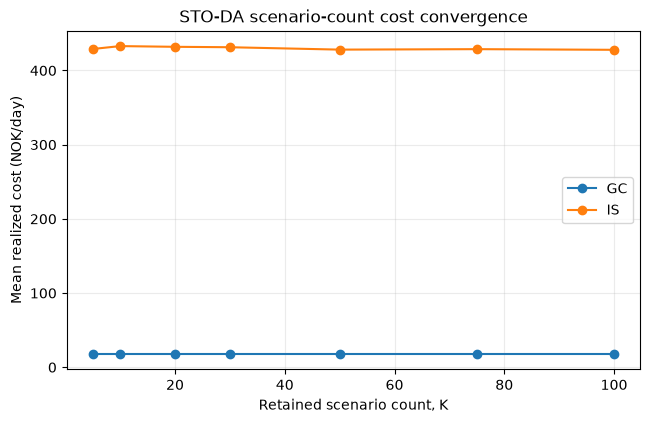

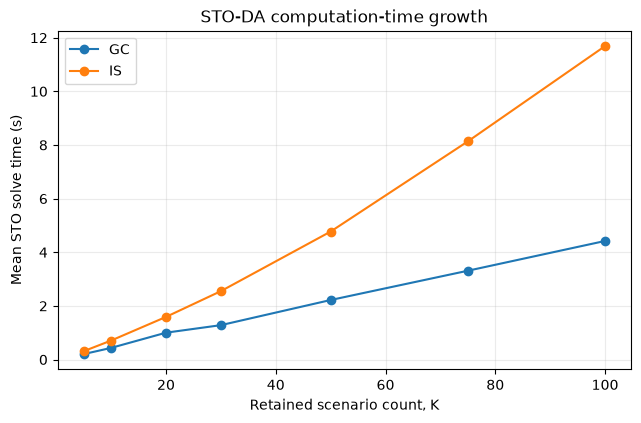

In [21]:
# Cost-convergence visualization after conv_summary is created.
fig,ax=plt.subplots(figsize=(7.4,4.4))
for mode,g in conv_summary.groupby('mode'):
    ax.plot(g['K'],g['mean_realized_cost_nok'],marker='o',label=mode)
ax.set_xlabel('Retained scenario count, K'); ax.set_ylabel('Mean realized cost (NOK/day)'); ax.set_title('STO-DA scenario-count cost convergence'); ax.grid(alpha=0.25); ax.legend(); plt.show()

fig,ax=plt.subplots(figsize=(7.4,4.4))
for mode,g in conv_summary.groupby('mode'):
    ax.plot(g['K'],g['mean_sto_solve_time_s'],marker='o',label=mode)
ax.set_xlabel('Retained scenario count, K'); ax.set_ylabel('Mean STO solve time (s)'); ax.set_title('STO-DA computation-time growth'); ax.grid(alpha=0.25); ax.legend(); plt.show()

## 10. Robustness check before freezing \(K\)

After the provisional \(K^\star\) is identified at \(\alpha=0.20\), compare only \(K^\star\) and \(K=100\) on the same 24 development days at \(\alpha=0.10\) and \(0.30\). This keeps the robustness check manageable while avoiding held-out-set tuning.

In [22]:
def run_selected_k_robustness(day_table,selected_K,alphas=(0.10,0.30),K_ref=K_REF):
    Ks=sorted(set([int(selected_K),int(K_ref)])); out=[]
    for alpha in alphas:
        part=run_k_convergence(day_table,alpha=alpha,Ks=Ks,modes=('GC','IS')); out.append(part)
    return pd.concat(out,ignore_index=True)

robust = run_selected_k_robustness(validation_days, selected_K)
robust.to_csv('sto_selected_k_robustness_development.csv',index=False)
display(robust.groupby(['alpha','mode','K'])[['realized_cost_nok','sto_solve_time_s']].mean())

Completed 1/24 development validation days
Completed 2/24 development validation days
Completed 3/24 development validation days
Completed 4/24 development validation days
Completed 5/24 development validation days
Completed 6/24 development validation days
Completed 7/24 development validation days
Completed 8/24 development validation days
Completed 9/24 development validation days
Completed 10/24 development validation days
Completed 11/24 development validation days
Completed 12/24 development validation days
Completed 13/24 development validation days
Completed 14/24 development validation days
Completed 15/24 development validation days
Completed 16/24 development validation days
Completed 17/24 development validation days
Completed 18/24 development validation days
Completed 19/24 development validation days
Completed 20/24 development validation days
Completed 21/24 development validation days
Completed 22/24 development validation days
Completed 23/24 development validation da

realized_cost_nok  sto_solve_time_s
alpha mode K                                       
0.1   GC   50           17.712487          2.302133
           100          17.712487          4.502416
      IS   50          427.051921          4.345217
           100         426.890893         10.386565
0.3   GC   50           17.712487          2.342622
           100          17.712487          4.815495
      IS   50          452.196650          5.972113
           100         452.215512         15.084956

## 11. Stop point

When the convergence and robustness tables are reviewed, freeze \(K^\star\). **Only then** proceed to the final 127-day held-out comparison of DET, STO, MPC, and PF and compute SMR/RR. Do not use the held-out results to revise \(K\).

In [23]:
import os

print(os.getcwd())

print("\nFiles:")
for f in os.listdir():
    print(f)

E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_STO_K_Convergence_Step

Files:
.ipynb_checkpoints
04_STO_DA_Scenario_Generation_BRA.ipynb
04_STO_DA_Scenario_Generation_BRA_K100_executed.ipynb
05_STO_DA_Pyomo_HiGHS_K_Convergence.ipynb
05_STO_DA_Pyomo_HiGHS_K_Convergence_PATCHED.ipynb
bra_outputs
config
data
README_STO_K_CONVERGENCE.txt
sto_k_convergence_development.csv
sto_k_convergence_summary.csv
sto_selected_k_robustness_development.csv


In [24]:
check_vars = [
    "backward_reduction_to_target",
    "N0",
    "BASE_SEED",
    "combined_daily",
    "source_daily",
    "oos"
]

for v in check_vars:
    print(v, v in globals())

backward_reduction_to_target False
N0 False
BASE_SEED True
combined_daily False
source_daily False
oos False


In [27]:
conv = pd.read_csv("sto_k_convergence_summary.csv")

print(conv.shape)
print(conv.columns.tolist())

conv.head()

(14, 10)
['mode', 'K', 'mean_realized_cost_nok', 'mean_sto_solve_time_s', 'paired_mean_diff_vs_Kref_nok', 'ci95_low', 'ci95_high', 'abs_paired_diff_percent_of_ref', 'ci_contains_zero', 'passes_mode_criterion']


,mode,K,mean_realized_cost_nok,mean_sto_solve_time_s,paired_mean_diff_vs_Kref_nok,ci95_low,ci95_high,abs_paired_diff_percent_of_ref,ci_contains_zero,passes_mode_criterion
0,GC,5,17.712487,0.203323,-2.960595e-16,-1.689143e-15,1.097024e-15,1.017512e-15,True,True
1,GC,10,17.712487,0.434793,2.960595e-16,-3.163862e-16,9.085052e-16,1.017512e-15,True,True
2,GC,20,17.712487,1.001670,2.960595e-16,-3.163862e-16,9.085052e-16,1.017512e-15,True,True
3,GC,30,17.712487,1.282579,2.960595e-16,-3.163862e-16,9.085052e-16,1.017512e-15,True,True
4,GC,50,17.712487,2.219892,2.960595e-16,-3.163862e-16,9.085052e-16,1.017512e-15,True,True


     K   mean_cost  solve_time
0    5  223.330165    0.257461
1   10  225.287679    0.571770
2   20  224.807312    1.295742
3   30  224.524926    1.916733
4   50  222.914548    3.495946
5   75  223.224059    5.723283
6  100  222.785533    8.054186


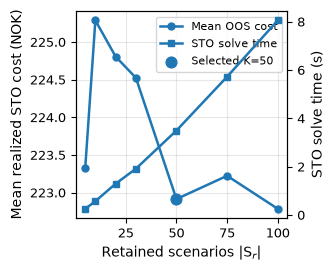

Saved PDF: forced_outage_results_v3\Fig1\Fig1_Scenario_Reduction_Convergence.pdf
Saved PNG: forced_outage_results_v3\Fig1\Fig1_Scenario_Reduction_Convergence.png


In [29]:
# ==========================================================
# Fig.1 Scenario Reduction Convergence (IEEE polished version)
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ----------------------------------------------------------
# Load convergence data
# ----------------------------------------------------------

conv = pd.read_csv("sto_k_convergence_summary.csv")


# Average across operating modes (GC + IS)
conv_plot = (
    conv.groupby("K")
    .agg(
        mean_cost=("mean_realized_cost_nok", "mean"),
        solve_time=("mean_sto_solve_time_s", "mean")
    )
    .reset_index()
)


print(conv_plot)


# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(3.45, 2.8))


# Cost curve
line1 = ax1.plot(
    conv_plot["K"],
    conv_plot["mean_cost"],
    marker="o",
    linewidth=1.8,
    markersize=5,
    label="Mean OOS cost"
)


ax1.set_xlabel(
    "Retained scenarios |S$_r$|",
    fontsize=10
)

ax1.set_ylabel(
    "Mean realized STO cost (NOK)",
    fontsize=10
)


ax1.tick_params(
    axis="both",
    labelsize=9
)


# ----------------------------------------------------------
# Highlight selected K=50
# ----------------------------------------------------------

selected = conv_plot[
    conv_plot["K"] == 50
]


ax1.scatter(
    selected["K"],
    selected["mean_cost"],
    s=60,
    zorder=5,
    label="Selected K=50"
)


# ----------------------------------------------------------
# Solve time curve
# ----------------------------------------------------------

ax2 = ax1.twinx()


line2 = ax2.plot(
    conv_plot["K"],
    conv_plot["solve_time"],
    marker="s",
    linewidth=1.8,
    markersize=5,
    label="STO solve time"
)


ax2.set_ylabel(
    "STO solve time (s)",
    fontsize=10
)


ax2.tick_params(
    axis="y",
    labelsize=9
)


# ----------------------------------------------------------
# Combined legend
# ----------------------------------------------------------

lines = line1 + line2
labels = [
    l.get_label()
    for l in lines
]

labels.append("Selected K=50")

handles = lines + [
    ax1.collections[0]
]


ax1.legend(
    handles,
    labels,
    fontsize=8,
    loc="best",
    frameon=True
)


# Grid
ax1.grid(
    True,
    alpha=0.3
)


# ----------------------------------------------------------
# IEEE formatting
# ----------------------------------------------------------

plt.tight_layout()


# Remove unnecessary top title
# (IEEE captions explain the figure)


# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

outdir = Path(
    "forced_outage_results_v3/Fig1"
)

outdir.mkdir(
    parents=True,
    exist_ok=True
)


pdf_path = (
    outdir /
    "Fig1_Scenario_Reduction_Convergence.pdf"
)

png_path = (
    outdir /
    "Fig1_Scenario_Reduction_Convergence.png"
)


fig.savefig(
    pdf_path,
    bbox_inches="tight"
)


fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)


plt.show()


print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

     K   mean_cost  solve_time
0    5  223.330165    0.257461
1   10  225.287679    0.571770
2   20  224.807312    1.295742
3   30  224.524926    1.916733
4   50  222.914548    3.495946
5   75  223.224059    5.723283
6  100  222.785533    8.054186


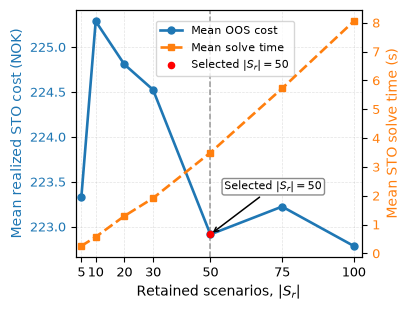

Saved PDF: forced_outage_results_v3\Fig1\Fig1_Scenario_Reduction_Convergence.pdf
Saved PNG: forced_outage_results_v3\Fig1\Fig1_Scenario_Reduction_Convergence.png


In [47]:
# ==========================================================
# Fig.1 Scenario Reduction Convergence (improved final version)
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------------------------------------
# Load convergence data
# ----------------------------------------------------------
conv = pd.read_csv("sto_k_convergence_summary.csv")

# Average across GC and IS
conv_plot = (
    conv.groupby("K", as_index=False)
    .agg(
        mean_cost=("mean_realized_cost_nok", "mean"),
        solve_time=("mean_sto_solve_time_s", "mean")
    )
    .sort_values("K")
)

print(conv_plot)

# ----------------------------------------------------------
# Selected scenario count
# ----------------------------------------------------------
selected_k = 50
selected = conv_plot[conv_plot["K"] == selected_k]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(4.2, 3.2))   # a bit bigger for clarity

# Left axis: Mean OOS cost
line1 = ax1.plot(
    conv_plot["K"],
    conv_plot["mean_cost"],
    color="tab:blue",
    marker="o",
    linewidth=1.9,
    markersize=5,
    label="Mean OOS cost"
)

ax1.set_xlabel(r"Retained scenarios, $|S_r|$", fontsize=10)
ax1.set_ylabel("Mean realized STO cost (NOK)", fontsize=10, color="tab:blue")
ax1.tick_params(axis="both", labelsize=9)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(conv_plot["K"])
ax1.set_xlim(3, 103)

# Highlight selected K=50
ax1.scatter(
    selected["K"],
    selected["mean_cost"],
    color="red",
    s=20,
    zorder=6,
    label=r"Selected $|S_r|=50$"
)

# Vertical reference line
ax1.axvline(
    x=selected_k,
    color="gray",
    linestyle="--",
    linewidth=1.1,
    alpha=0.8
)

# Annotation for selected K=50
if not selected.empty:
    x_sel = float(selected["K"].iloc[0])
    y_sel = float(selected["mean_cost"].iloc[0])

    ax1.annotate(
        r"Selected $|S_r|=50$",
        xy=(x_sel, y_sel),
        xytext=(10, 30),   # moved upward/right
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.9),
        arrowprops=dict(arrowstyle="->", lw=1.1, color="black")
    )

# Right axis: Solve time
ax2 = ax1.twinx()
line2 = ax2.plot(
    conv_plot["K"],
    conv_plot["solve_time"],
    color="tab:orange",
    marker="s",
    linestyle="--",
    linewidth=1.9,
    markersize=5,
    label="Mean solve time"
)

ax2.set_ylabel("Mean STO solve time (s)", fontsize=10, color="tab:orange")
ax2.tick_params(axis="y", labelsize=9, labelcolor="tab:orange")

# Grid
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)

# Combined legend
handles = line1 + line2 + [ax1.collections[0]]
labels = [h.get_label() for h in handles]

ax1.legend(
    handles,
    labels,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.52, 0.98),
    frameon=True,
    ncol=1
)

# Layout
plt.tight_layout()

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------
outdir = Path("forced_outage_results_v3/Fig1")
outdir.mkdir(parents=True, exist_ok=True)

pdf_path = outdir / "Fig1_Scenario_Reduction_Convergence.pdf"
png_path = outdir / "Fig1_Scenario_Reduction_Convergence.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

plt.show()

print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)